# Transfer matrix: reflectance of a metal-oxide multilayer

This notebook walks the model from one interface up to the six measured samples.
Everything it calls lives in `src/plasmonics`; nothing is defined here, so the
notebook stays readable and the library stays testable.

Run order: interface, single metal film, then the samples.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np

from plasmonics import SAMPLES, default_registry, reflectance_vs_angle
from plasmonics.plotting import POL_COLOR, POL_LABEL, plot_curves

registry = default_registry()
theta = np.arange(20.0, 80.01, 0.1)
registry

{'air': Dispersion('air', lossless, 0.100-100.000 um),
 'bk7': Dispersion('bk7', lossless, 0.300-2.500 um),
 'gold': Dispersion('gold', absorbing, 0.188-1.937 um),
 'copper': Dispersion('copper', absorbing, 0.188-1.937 um),
 'ta2o5': Dispersion('ta2o5', absorbing, 0.500-1000.000 um),
 'sio2': Dispersion('sio2', lossless, 0.210-6.700 um),
 'quartz': Dispersion('sio2', lossless, 0.210-6.700 um)}

## 1. One interface: Brewster angle and total internal reflection

The bare BK7/air interface is the calibration case. TM vanishes at the Brewster
angle; both polarisations saturate past the critical angle near 41 degrees. Every
measured curve is aligned to that 41 degree edge.

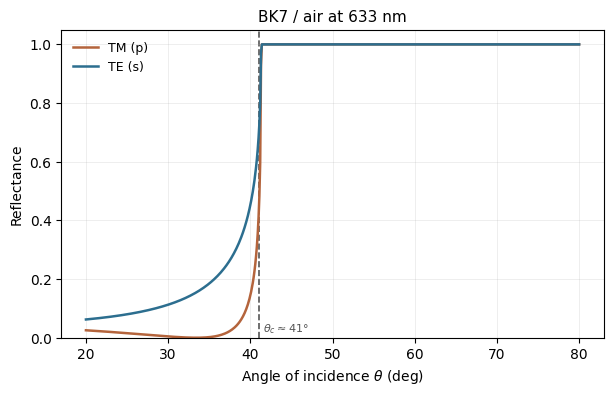

In [2]:
lam = 0.633
media = ["bk7", "air"]
thicknesses = [0.0, 0.0]
n_list = registry.indices(media, lam)

curves = {
    POL_LABEL[pol]: (
        reflectance_vs_angle(n_list, thicknesses, lam, theta, pol),
        {"color": POL_COLOR[pol]},
    )
    for pol in ("p", "s")
}

fig, ax = plt.subplots(figsize=(7, 4))
plot_curves(ax, theta, curves, title="BK7 / air at 633 nm", mark_oil=False)
plt.show()

## 2. A thin gold film: the plasmon resonance appears in TM only

Adding 22 nm of gold opens a sharp dip in TM past the critical angle, where the
evanescent field couples to the surface plasmon. TE has no such solution at a
single metal/dielectric interface and stays smooth.

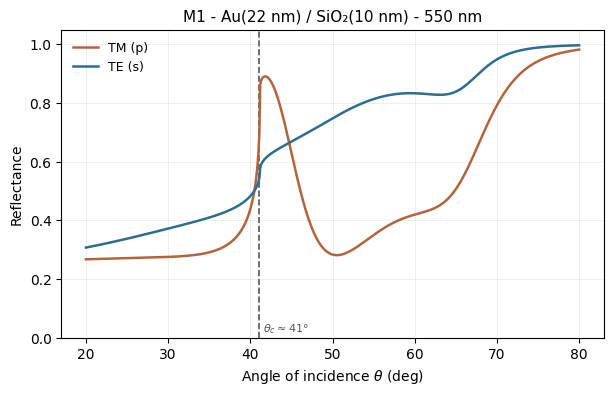

In [3]:
m1 = SAMPLES["M1"]
lam = 0.550
n_list = registry.indices(m1.media, lam)

curves = {
    POL_LABEL[pol]: (
        reflectance_vs_angle(n_list, m1.thicknesses, lam, theta, pol),
        {"color": POL_COLOR[pol]},
    )
    for pol in ("p", "s")
}

fig, ax = plt.subplots(figsize=(7, 4))
plot_curves(ax, theta, curves, title=f"M1 - {m1.label} - 550 nm", mark_oil=False)
plt.show()

## 3. Thickening the dielectric: a minimum shows up in TE

M4, M5 and M7 differ only in how much Ta2O5 sits on top of the copper: 20, 30 and
70 nm. Sweeping that one number is the cleanest way to see the effect the report
is about. Watch TE go from featureless to carrying a narrow minimum of its own,
while the TM plasmon dip washes out.

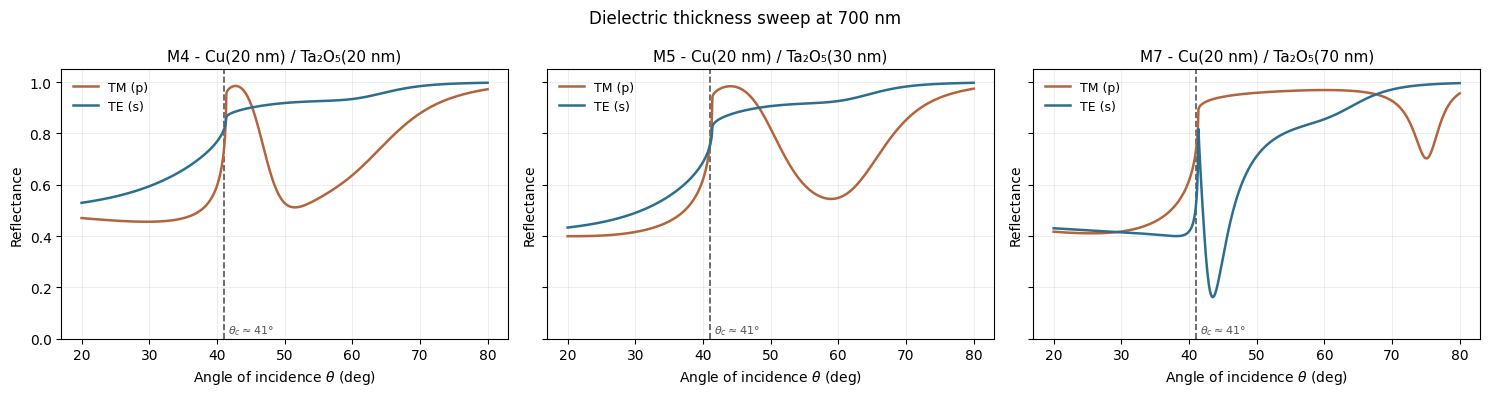

In [4]:
lam = 0.700
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, key in zip(axes, ["M4", "M5", "M7"]):
    sample = SAMPLES[key]
    n_list = registry.indices(sample.media, lam)
    curves = {
        POL_LABEL[pol]: (
            reflectance_vs_angle(n_list, sample.thicknesses, lam, theta, pol),
            {"color": POL_COLOR[pol]},
        )
        for pol in ("p", "s")
    }
    plot_curves(ax, theta, curves, title=f"{key} - {sample.label}", mark_oil=False)

fig.suptitle(f"Dielectric thickness sweep at {lam * 1000:.0f} nm", fontsize=12)
fig.tight_layout()
plt.show()

## 4. Where the TE minimum sits, sample by sample

A table beats six more plots here. The angle is where TE reaches its deepest
point between the critical angle and the onset of the oil artefact; a value at
the 42 degree edge means the curve is monotonic and there is no minimum at all.

In [5]:
window = (theta >= 42.0) & (theta <= 70.0)

print(f"{'sample':<7}{'lambda':>9}{'TE min':>10}{'at angle':>11}   stack")
print('-' * 70)
for key, sample in SAMPLES.items():
    for lam_nm in (550, 633, 700):
        lam = lam_nm / 1000.0
        n_list = registry.indices(sample.media, lam)
        R = reflectance_vs_angle(n_list, sample.thicknesses, lam, theta, 's')
        i = int(np.argmin(R[window]))
        print(
            f'{key:<7}{lam_nm:>6} nm{R[window][i]:>10.3f}'
            f'{theta[window][i]:>9.1f} deg   {sample.label}'
        )


sample    lambda    TE min   at angle   stack
----------------------------------------------------------------------
M1        550 nm     0.616     42.0 deg   Au(22 nm) / SiO₂(10 nm)
M1        633 nm     0.886     42.0 deg   Au(22 nm) / SiO₂(10 nm)
M1        700 nm     0.942     42.0 deg   Au(22 nm) / SiO₂(10 nm)
M4        550 nm     0.137     42.0 deg   Cu(20 nm) / Ta₂O₅(20 nm)
M4        633 nm     0.745     42.0 deg   Cu(20 nm) / Ta₂O₅(20 nm)
M4        700 nm     0.877     42.0 deg   Cu(20 nm) / Ta₂O₅(20 nm)
M5        550 nm     0.026     42.0 deg   Cu(20 nm) / Ta₂O₅(30 nm)
M5        633 nm     0.653     42.0 deg   Cu(20 nm) / Ta₂O₅(30 nm)


M5        700 nm     0.848     42.0 deg   Cu(20 nm) / Ta₂O₅(30 nm)
M6        550 nm     0.087     42.0 deg   Cu(20 nm) / Ta₂O₅(70 nm) / Cu(20 nm) / Ta₂O₅(91 nm)
M6        633 nm     0.444     65.2 deg   Cu(20 nm) / Ta₂O₅(70 nm) / Cu(20 nm) / Ta₂O₅(91 nm)
M6        700 nm     0.322     53.9 deg   Cu(20 nm) / Ta₂O₅(70 nm) / Cu(20 nm) / Ta₂O₅(91 nm)
M7        550 nm     0.144     63.3 deg   Cu(20 nm) / Ta₂O₅(70 nm)
M7        633 nm     0.081     50.2 deg   Cu(20 nm) / Ta₂O₅(70 nm)
M7        700 nm     0.162     43.5 deg   Cu(20 nm) / Ta₂O₅(70 nm)
M8        550 nm     0.013     66.3 deg   Au(20 nm) / Ta₂O₅(70 nm)
M8        633 nm     0.197     50.0 deg   Au(20 nm) / Ta₂O₅(70 nm)


M8        700 nm     0.341     43.8 deg   Au(20 nm) / Ta₂O₅(70 nm)
